In [2]:
import gc
import sklearn
import imblearn
import numpy as np
import keras_tuner
import tensorflow as tf
from collections import Counter
import matplotlib.pyplot as plt
import Modules.constants as constants
import Modules.ds_loader as ds_loader
import os
print(os.cpu_count())
SAMPLE_PERCENTAGE = 1.0

DATA_PATH = constants.DATASET

TRAIN_DIR = DATA_PATH / "train"
VAL_DIR = DATA_PATH / "val"
TEST_DIR = DATA_PATH / "test"

X_train, y_train = ds_loader.load_data(TRAIN_DIR)
X_test, y_test = ds_loader.load_data(TEST_DIR)
X_val, y_val = ds_loader.load_data(VAL_DIR)

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

16
[ OK ] Loaded 7565 samples with shape (500, 12)
[ OK ] Loaded 1770 samples with shape (500, 12)
[ OK ] Loaded 1770 samples with shape (500, 12)


In [4]:
print("Unique classes in y:", np.unique(y_train))
print("Datatype:", print(X_train.dtype), print(y_train.dtype))
print(f"Min and Max of X_train: {np.min(X_train)}, {np.max(X_train)}")
print(f"Min and Max of X_val: {np.min(X_val)}, {np.max(X_val)}")
print(f"Min and Max of X_test: {np.min(X_test)}, {np.max(X_test)}")
print(f"NaNs in X: {np.isnan(X_train).sum()}")
print(f"Infs in X: {np.isinf(X_train).sum()}")
print(f"Class distribution: {Counter(y_train)}")

Unique classes in y: [0 1 2 3]
float32
int32
Datatype: None None
Min and Max of X_train: 0.0, 1.0000001192092896
Min and Max of X_val: -9.52983283996582, 11.054253578186035
Min and Max of X_test: -11.602144241333008, 13.575825691223145
NaNs in X: 0
Infs in X: 0
Class distribution: Counter({np.int32(2): 2825, np.int32(1): 1598, np.int32(3): 1573, np.int32(0): 1569})


In [5]:
X_train_flat = X_train.reshape((X_train.shape[0],-1))
smote = imblearn.over_sampling.SMOTE(random_state=42)
X_resampled, y_train = smote.fit_resample(X_train_flat, y_train)
X_train = X_resampled.reshape((-1, *X_train.shape[1:]))

print(f"Class distribution: {Counter(y_train)}")

Class distribution: Counter({np.int32(0): 2825, np.int32(1): 2825, np.int32(2): 2825, np.int32(3): 2825})


In [6]:
# 1-D convolutional ResNet model 
# https://pmc.ncbi.nlm.nih.gov/articles/PMC10128986/#sec012
class Resnet(keras_tuner.HyperModel):
    def residual_block(self, inputs, c_units, p_units, k_units):
        # C1 BLOCK
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=1, padding='same')(inputs)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=1, padding='same')(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        # SC
        s = tf.keras.layers.Conv1D(filters=c_units, kernel_size=1, strides=1, padding='same')(inputs)
        x = tf.keras.layers.Add()([x, s])
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling1D(p_units, strides=2)(x)
        return x


    def build(self, hp):
        gc.collect()
        tf.keras.backend.clear_session()
        # HYPERPARAMS
        n_layer = 3
        k_units = 3
        p_units = 5
        #p_units = hp.Int("p_units", min_value=2, max_value=10, step=1)
        c_units = hp.Choice("c_units", [128])
        d_units_0 = hp.Choice("d_units_0", [512])
        d_units_1 = hp.Choice('d_units_coef', [2,4])
        dropout_0 = hp.Float('dropout_0', min_value = 0.3, max_value=0.5, step=0.05)
        dropout_1 = hp.Float('dropout_1', min_value = 0.3, max_value=0.5, step=0.05)
        
        # INPUT LAYER
        inputs = tf.keras.Input(shape=(500,12))
        
        # RESIDUALS
        x = self.residual_block(inputs, c_units, p_units, k_units)
        filter_size = c_units
        for i in range(1, n_layer):
            #filter_size *= 2  
            x = self.residual_block(x, filter_size, p_units, k_units)

        # CLASSIFIER
        x = tf.keras.layers.Flatten()(x)
        x = tf.keras.layers.Dense(d_units_0, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_0)(x)  
        x = tf.keras.layers.Dense(d_units_0 // d_units_1, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_1)(x)  

        # OUTPUT
        outputs = tf.keras.layers.Dense(4, activation='softmax')(x)
        
        model = tf.keras.Model(inputs, outputs)
        optimizer = tf.keras.optimizers.Adam(
                        learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-3),
                        weight_decay=hp.Choice('weight_decay',[1e-3,1e-4,1e-5,0.0])
                    )
        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        
        
        return model
    
    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            batch_size= hp.Choice("batch_size", [32]),
            *args,
            **kwargs,
        ) 

In [7]:
RDIR="Results/RES_W5000_L3/" 
MDIR= RDIR + "RES_W5000_L3.keras"
CDIR= RDIR + "C_RES_W5000_L3.keras"
CVDIR = RDIR + "RES_W5000_L3_CV.keras"
tuner = keras_tuner.BayesianOptimization(
    Resnet(),
    max_trials=20,
    overwrite=False,
    objective='val_accuracy',
    directory=RDIR,
    project_name="RES_W5000_L3_00",
    )

tuner.search_space_summary()

Reloading Tuner from Results/RES_W5000_L3/RES_W5000_L3_00/tuner0.json
Search space summary
Default search space size: 8
c_units (Choice)
{'default': 64, 'conditions': [], 'values': [64], 'ordered': True}
d_units_0 (Choice)
{'default': 128, 'conditions': [], 'values': [128], 'ordered': True}
d_units_coef (Choice)
{'default': 2, 'conditions': [], 'values': [2, 4], 'ordered': True}
dropout_0 (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.05, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.05, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.001, 'step': None, 'sampling': 'linear'}
weight_decay (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001, 1e-05, 0.0], 'ordered': True}
batch_size (Choice)
{'default': 32, 'conditions': [], 'values': [32], 'ordered': True}


I0000 00:00:1744615520.574817  242028 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2182 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [8]:
callback_list = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",mode="max", restore_best_weights=True,patience=5, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(filepath=CDIR,monitor='val_accuracy', save_best_only=True, save_weights_only=False,    
    verbose=0)
]
tuner.search(
    X_train, y_train, 
    epochs = 150,
    validation_data=(X_val, y_val),
    callbacks=callback_list 
)

Trial 20 Complete [00h 00m 56s]
val_accuracy: 0.9163841605186462

Best val_accuracy So Far: 0.9163841605186462
Total elapsed time: 1d 23h 32m 33s


In [10]:
tuner.results_summary()

Results summary
Results in Results/RES_W5000_L3/RES_W5000_L3_00
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 09 summary
Hyperparameters:
c_units: 64
d_units_0: 128
d_units_coef: 2
dropout_0: 0.4
dropout_1: 0.3
learning_rate: 0.0008135335621876089
weight_decay: 0.001
batch_size: 32
Score: 0.9163841605186462

Trial 19 summary
Hyperparameters:
c_units: 64
d_units_0: 128
d_units_coef: 2
dropout_0: 0.35
dropout_1: 0.4
learning_rate: 0.000433956332628634
weight_decay: 0.0
batch_size: 32
Score: 0.9163841605186462

Trial 11 summary
Hyperparameters:
c_units: 64
d_units_0: 128
d_units_coef: 4
dropout_0: 0.3
dropout_1: 0.35
learning_rate: 0.0003019826365751395
weight_decay: 1e-05
batch_size: 32
Score: 0.9067796468734741

Trial 08 summary
Hyperparameters:
c_units: 64
d_units_0: 128
d_units_coef: 2
dropout_0: 0.5
dropout_1: 0.4
learning_rate: 0.0005184872073773723
weight_decay: 0.0
batch_size: 32
Score: 0.905649721622467

Trial 10 summary
Hyperparameters:
c_units: 6

In [11]:
models = tuner.get_best_models(num_models=1)
best_model = models[0]
best_model.summary()
best_model.save(MDIR) 

/home/capitan/.venv/tenv/lib64/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 86 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 500, 64)   │      2,368 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 500, 64)   │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 500, 64)   │        256 │ re_lu[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 64)   │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 500, 64)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 500, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 248, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 248, 64)   │     12,352 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 248, 64)   │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 248, 64)   │        256 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 248, 64)   │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 248, 64)   │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 248, 64)   │        256 │ re_lu_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 248, 64)   │      4,160 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 248, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 567,556 (2.17 MB)

 Trainable params: 566,404 (2.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [12]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0] 
print(best_hps.values)

{'c_units': 64, 'd_units_0': 128, 'd_units_coef': 2, 'dropout_0': 0.4, 'dropout_1': 0.3, 'learning_rate': 0.0008135335621876089, 'weight_decay': 0.001, 'batch_size': 32}


In [13]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, batch_size=32)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8578 - loss: 0.4885
Test Loss: 0.3212473392486572
Test Accuracy: 0.909604549407959


In [14]:
y_pred = best_model.predict(X_test)

if y_pred.shape[1] == 1:  
    y_pred_binary = (y_pred > 0.5).astype(int)
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred)  
else:
    y_pred_binary = np.argmax(y_pred, axis=1)  
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')

print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_binary))
print(f"AUC: {auc}")

y_train_pred = best_model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

print("Classification Report (Train Data):")
print(sklearn.metrics.classification_report(y_train, y_train_pred))

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       360
           1       0.79      0.94      0.86       361
           2       0.95      0.99      0.97       683
           3       0.97      0.87      0.92       366

    accuracy                           0.91      1770
   macro avg       0.91      0.89      0.89      1770
weighted avg       0.91      0.91      0.91      1770

AUC: 0.985195746647513
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2825
           1       0.95      0.93      0.94      2825
           2       0.97      0.99      0.98      2825
           3       0.99      0.95      0.97      2825

    accuracy                           0.96     11300
   macro avg       0.96      0.96      0.96     11300
weighted a

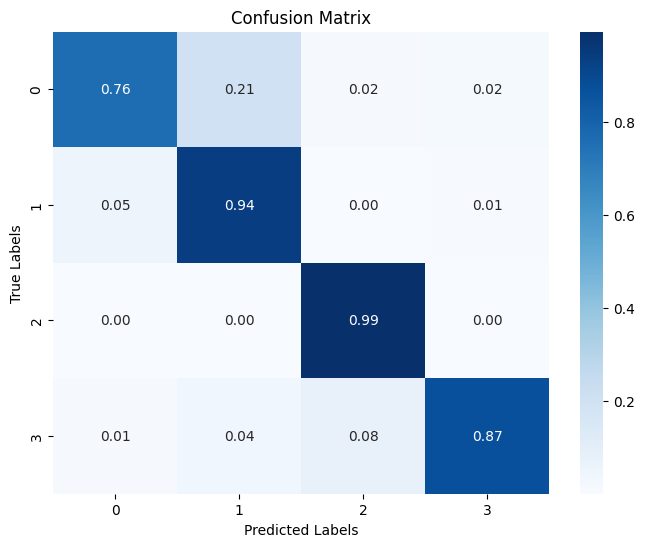

In [15]:
import seaborn as sns
y_pred_class = np.argmax(y_pred, axis=1)  
cm = sklearn.metrics.confusion_matrix(y_test, y_pred_class, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [16]:
kfold = sklearn.model_selection.StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_accuracies = []
fold_histories = []

best_accuracy = 0.0
best_model = None  

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f"\n--- Fold {fold+1} ---")

    fold_callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)
    ]
    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]

    model = Resnet().build(best_hps)

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        callbacks=fold_callbacks,
        verbose=1
    )

    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Validation Accuracy: {val_accuracy:.4f}")
    fold_accuracies.append(val_accuracy)
    fold_histories.append(history)

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_model = model
        model.save(CVDIR) 
        print(f"Saved best model from Fold {fold+1} with Accuracy: {val_accuracy:.4f}")



--- Fold 1 ---
Epoch 1/100
315/318 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4233 - loss: 1.4668

2025-04-14 09:38:18.456402: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.03GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


318/318 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.4247 - loss: 1.4622 - val_accuracy: 0.2681 - val_loss: 1.9640
Epoch 2/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7169 - loss: 0.7324 - val_accuracy: 0.8150 - val_loss: 0.5260
Epoch 3/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7891 - loss: 0.5668 - val_accuracy: 0.8867 - val_loss: 0.3440
Epoch 4/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8705 - loss: 0.3843 - val_accuracy: 0.9018 - val_loss: 0.2870
Epoch 5/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8955 - loss: 0.3014 - val_accuracy: 0.9195 - val_loss: 0.2345
Epoch 6/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9152 - loss: 0.2625 - val_accuracy: 0.8628 - val_loss: 0.3274
Epoch 7/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9256 - loss: 0.2219 - val_accuracy: 0.9381 - val_loss: 0.1689
Epoch 8/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9289 - loss: 0.2160 - val_accuracy: 0.93

In [17]:
print("Cross-validation accuracies:", fold_accuracies)
print("Average CV accuracy:", np.mean(fold_accuracies))
print("Max CV accuracy:", np.max(fold_accuracies))

Cross-validation accuracies: [0.952212393283844, 0.9530973434448242, 0.9530973434448242, 0.9646017551422119, 0.9584071040153503, 0.9424778819084167, 0.9637168049812317, 0.9654867053031921, 0.9486725926399231, 0.9672566652297974]
Average CV accuracy: 0.9569026589393616
Max CV accuracy: 0.9672566652297974


In [19]:
cv_model = tf.keras.models.load_model(CVDIR)
cv_model.evaluate(X_test, y_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8351 - loss: 0.9358


[0.5491165518760681, 0.901129961013794]

In [25]:
test_loss, test_accuracy = cv_model.evaluate(X_test, y_test, batch_size=32)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8351 - loss: 0.9358
Test Loss: 0.5491165518760681
Test Accuracy: 0.901129961013794


In [26]:
y_pred = cv_model.predict(X_test)

if y_pred.shape[1] == 1:  
    y_pred_binary = (y_pred > 0.5).astype(int)
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred)  
else:
    y_pred_binary = np.argmax(y_pred, axis=1)  
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')

print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_binary))
print(f"AUC: {auc}")

y_train_pred = cv_model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

print("Classification Report (Train Data):")
print(sklearn.metrics.classification_report(y_train, y_train_pred))

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       360
           1       0.78      0.93      0.84       361
           2       0.95      1.00      0.97       683
           3       0.96      0.88      0.92       366

    accuracy                           0.90      1770
   macro avg       0.90      0.88      0.88      1770
weighted avg       0.91      0.90      0.90      1770

AUC: 0.9776207028410446
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2825
           1       0.99      0.96      0.98      2825
           2       0.99      1.00      0.99      2825
           3       0.99      0.99      0.99      2825

    accuracy                           0.99     11300
   macro avg       0.99      0.99      0.99     11300
weighted a

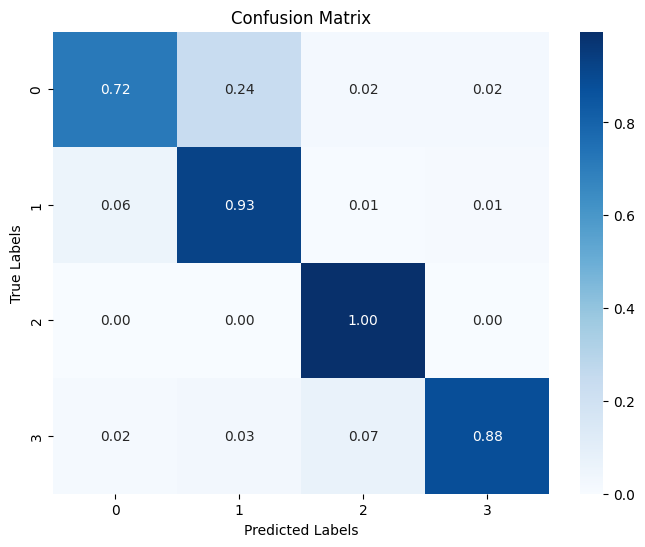

In [27]:
import seaborn as sns
y_pred_class = np.argmax(y_pred, axis=1)  
cm = sklearn.metrics.confusion_matrix(y_test, y_pred_class, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

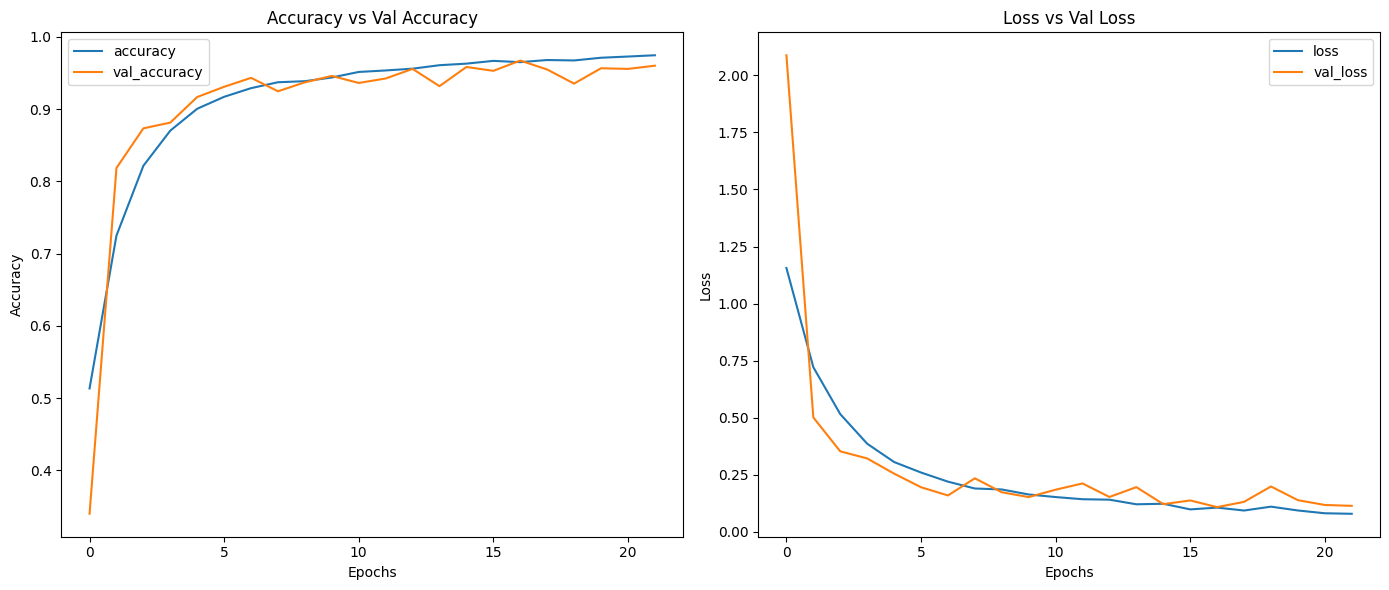

In [28]:

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(history.history['accuracy'], label='accuracy')
ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
ax[0].set_title('Accuracy vs Val Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='loss')
ax[1].plot(history.history['val_loss'], label='val_loss')
ax[1].set_title('Loss vs Val Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()